In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("Stars.csv")
print("Dataset loaded successfully")
print("Shape:",df.shape)

Dataset loaded successfully
Shape: (240, 7)


In [3]:
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
 6   Type            240 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 14.7 KB


In [5]:
df.describe()

,Temperature,L,R,A_M,Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [6]:
df.isnull().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
Type              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.rename(columns={
    "Temperature":"Temperature",
    "L":"Luminosity",
    "R":"Radius",
    "A_M":"Magnitude",
    "Type":"star_type",
    "Spectral_class":"Spectral_class",
          "color":"star_color"
}, inplace=True)
        
df.head()    


,Temperature,Luminosity,Radius,Magnitude,Color,Spectral_Class,star_type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


In [9]:
df["star_type"].value_counts().sort_index()

star_type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

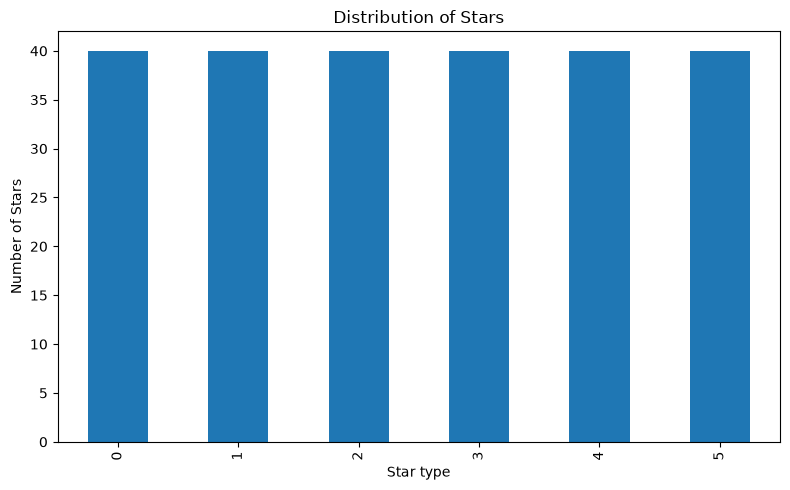

In [14]:
plt.figure(figsize=(8,5))
df["star_type"].value_counts().sort_index().plot.bar()
plt.xlabel("Star type")
plt.ylabel("Number of Stars")
plt.title("Distribution of Stars")
plt.tight_layout()
plt.show()

In [16]:
print("Minimum temperature:",df["Temperature"].min(),"K")
print("Maximum temperature:",df["Temperature"].max(),"K")
print("Mean temperature:",round(df["Temperature"].mean(),2),"K")
print("Median temperature:",df["Temperature"].median(),"K")

Minimum temperature: 1939 K
Maximum temperature: 40000 K
Mean temperature: 10497.46 K
Median temperature: 5776.0 K


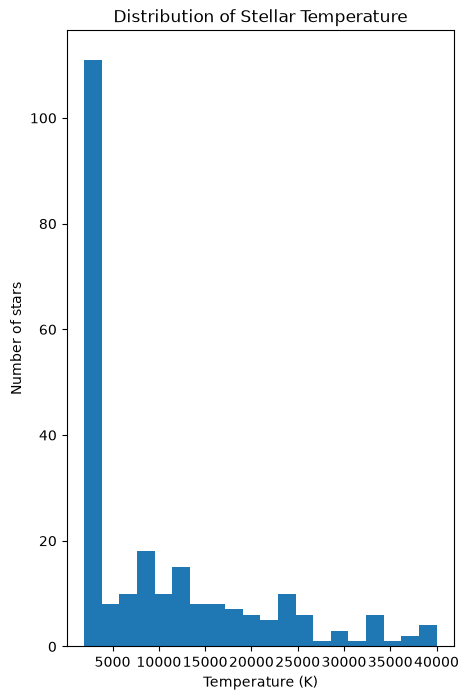

In [17]:
plt.figure(figsize=(5,8))
plt.hist(df["Temperature"],bins=20)
plt.xlabel("Temperature (K)")
plt.ylabel("Number of stars")
plt.title("Distribution of Stellar Temperature")
plt.show()
    

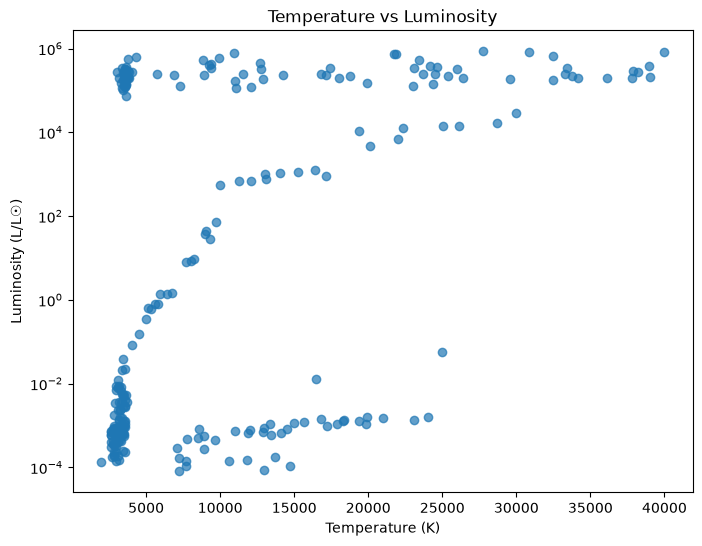

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(df["Temperature"], df["Luminosity"], alpha=0.7)
plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity (L/L☉)")
plt.title("Temperature vs Luminosity")
plt.yscale("log")
plt.show()

In [20]:
correlation=df["Temperature"].corr(df["Luminosity"])
print("Temperature-Luminosity correlation:",round(correlation,3))

Temperature-Luminosity correlation: 0.393


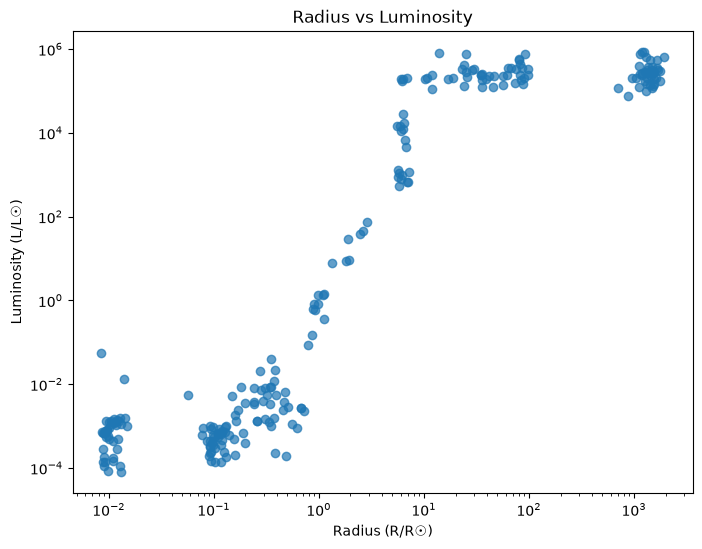

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df["Radius"], df["Luminosity"], alpha=0.7)
plt.xlabel("Radius (R/R☉)")
plt.ylabel("Luminosity (L/L☉)")
plt.title("Radius vs Luminosity")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [22]:
correlation = df["Radius"].corr(df["Luminosity"])
print("Radius-Luminosity correlation:", round(correlation, 3))

Radius-Luminosity correlation: 0.527


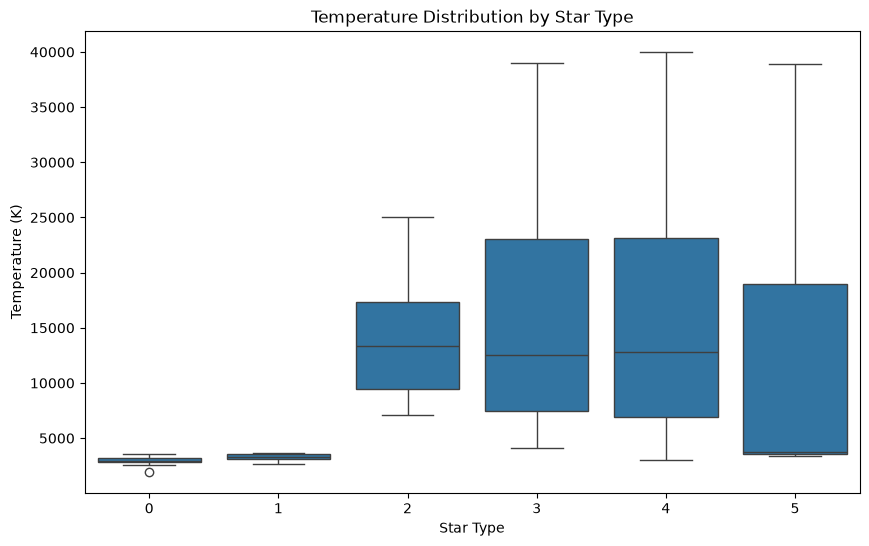

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="star_type",
    y="Temperature")
plt.xlabel("Star Type")
plt.ylabel("Temperature (K)")
plt.title("Temperature Distribution by Star Type")
plt.show()

In [25]:
correlation = df[ ["Temperature", "Luminosity", "Radius", "Magnitude"]].corr()
print(correlation.round(2))

             Temperature  Luminosity  Radius  Magnitude
Temperature         1.00        0.39    0.06      -0.42
Luminosity          0.39        1.00    0.53      -0.69
Radius              0.06        0.53    1.00      -0.61
Magnitude          -0.42       -0.69   -0.61       1.00


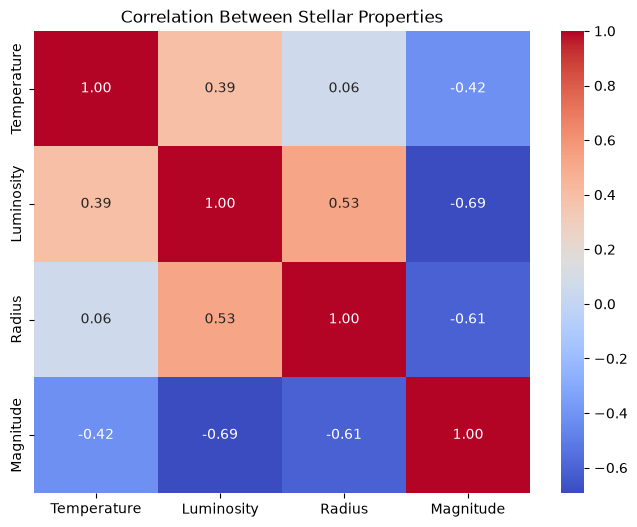

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")
plt.title("Correlation Between Stellar Properties")
plt.show()

In [27]:
hottest = df.loc[df["Temperature"].idxmax()]
print(hottest)

Temperature          40000
Luminosity        813000.0
Radius                14.0
Magnitude            -6.23
Color                 Blue
Spectral_Class           O
star_type                4
Name: 101, dtype: object


In [28]:
most_luminous = df.loc[df["Luminosity"].idxmax()]
print(most_luminous)

Temperature            27739
Luminosity          849420.0
Radius                1252.0
Magnitude              -7.59
Color             Blue-white
Spectral_Class             B
star_type                  5
Name: 233, dtype: object


In [29]:
largest = df.loc[df["Radius"].idxmax()]
print(largest)

Temperature          32489
Luminosity        648430.0
Radius              1948.5
Magnitude           -10.84
Color                 Blue
Spectral_Class           O
star_type                5
Name: 232, dtype: object


In [30]:
df.groupby("star_type")[["Temperature","Luminosity","Radius","Magnitude"]].mean().round(2)

,Temperature,Luminosity,Radius,Magnitude
star_type,,,,
0,2997.95,0.00,0.11,17.56
1,3283.82,0.01,0.35,12.54
2,13931.45,0.00,0.01,12.58
3,16018.00,32067.39,4.43,-0.37
4,15347.85,301816.25,51.15,-6.37
5,11405.70,309246.53,1366.90,-9.65


In [31]:
Q1 = df["Luminosity"].quantile(0.25)
Q3 = df["Luminosity"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
outliers = df[df["Luminosity"] > upper_limit]
print("Possible luminosity outliers:", len(outliers))
print("Upper limit:", upper_limit)

Possible luminosity outliers: 12
Upper limit: 495124.998702875


In [33]:
df.to_csv("Star_week2_cleaned.csv",index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
